Aim:
To develop a Python-based speech-to-text system that converts spoken commands into text in real time,
provides meaningful user feedback, handles errors gracefully, and allows comparison of different
recognition methods.

In [2]:
!pip install SpeechRecognition

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 76.2 MB/s eta 0:00:00


In [4]:
!pip install openai-whisper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 10.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803979 sha256=330987d862c29c071e89ba37ffe843abb38c47db3671ac2e91e87daba2d4255a
  Stored in directory: /root/.cache/pip/wheels/61/d2/20/09ec9bef734d126cba375b15898010b6cc28578d8afdde5869
Successfully built openai-whisper


In [6]:
!pip install jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 28.1 MB/s eta 0:00:00


In [17]:
!pip install vosk

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 43.2 MB/s eta 0:00:00
  Created wheel for srt: filename=srt-3.5.3-py3-none-any.whl size=22427 sha256=826eae4535a1d49a2d31757dc156706dbc9807d058f70ac60b92e95261be9dfb
  Stored in directory: /root/.cache/pip/wheels/7e/75/5b/e1d5c3756631e4bda806f6cc9640153b39484bb6f7b0b8def3
Successfully built srt


In [28]:
!pip install pocketsphinx


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.2/29.2 MB 12.4 MB/s eta 0:00:00


In [18]:
import speech_recognition as sr
import whisper
from vosk import Model, KaldiRecognizer
import wave
import json
import time
import matplotlib.pyplot as plt
import pandas as pd
from jiwer import wer
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

In [19]:
# =============================================================================
# SETUP
# =============================================================================
print("🚀 Initializing Speech-to-Text System...")
print("Loading models (this may take a few moments)...")

# Load Whisper
whisper_model = whisper.load_model("base")

# Download and load Vosk model
print("Downloading Vosk model...")
!wget -q https://alphacephei.com/vosk/models/vosk-model-small-en-us-0.15.zip
!unzip -q vosk-model-small-en-us-0.15.zip
vosk_model = Model("vosk-model-small-en-us-0.15")

# Initialize recognizer
recognizer = sr.Recognizer()

print("✓ All models loaded successfully!\n")

🚀 Initializing Speech-to-Text System...
Loading models (this may take a few moments)...
✓ All models loaded successfully!



In [24]:
# =============================================================================
# UPLOAD AUDIO FILES
# =============================================================================
print("📁 Please upload your audio files (.wav format recommended):")
uploaded = files.upload()
print(f"\n✓ {len(uploaded)} file(s) uploaded successfully!\n")

# Audio type options
audio_types = ['Clear male voice', 'Clear female voice', 'Fast speech',
               'Noisy background', 'Soft voice']

# Store all results
all_results = []


📁 Please upload your audio files (.wav format recommended):


Saving clear female.wav to clear female.wav
Saving clear male.wav to clear male.wav
Saving fast.wav to fast.wav
Saving noisy.wav to noisy.wav

✓ 4 file(s) uploaded successfully!



In [29]:
# =============================================================================
# PROCESS EACH AUDIO FILE
# =============================================================================
for file_num, filename in enumerate(uploaded.keys(), 1):
    print("\n" + "="*70)
    print(f"📄 FILE {file_num}/{len(uploaded)}: {filename}")
    print("="*70)

    # Get audio type from user
    print("\nWhat type of audio is this?")
    for i, t in enumerate(audio_types, 1):
        print(f"  {i}. {t}")
    audio_type_idx = int(input("Enter number (1-5): ")) - 1
    audio_type = audio_types[audio_type_idx]

    # Get ground truth
    ground_truth = input("\nEnter the actual text (ground truth): ")
    print()

    # Load audio file for SpeechRecognition
    print("📂 Loading audio...")
    with sr.AudioFile(filename) as source:
        audio_data = recognizer.record(source)
    print("✓ Audio loaded!\n")

    # -------------------------------------------------------------------------
    # METHOD 1: GOOGLE SPEECH API
    # -------------------------------------------------------------------------
    print("🔍 METHOD 1: Google Speech API (Online)")
    print("-" * 70)

    try:
        start_time = time.time()
        google_text = recognizer.recognize_google(audio_data, show_all=True)
        google_time = time.time() - start_time

        if google_text and 'alternative' in google_text:
            google_transcript = google_text['alternative'][0]['transcript']
            google_confidence = google_text['alternative'][0].get('confidence', 0.0) * 100
            google_wer_score = wer(ground_truth, google_transcript) * 100

            print(f"✓ Recognition successful!")
            print(f"📝 Transcription: '{google_transcript}'")
            print(f"🎯 Confidence: {google_confidence:.1f}%")
            print(f"📊 WER: {google_wer_score:.2f}%")
            print(f"⏱️  Time: {google_time:.2f}s")

            google_success = True
        else:
            print("❌ No transcription returned")
            google_transcript = "Error"
            google_confidence = 0
            google_wer_score = 100
            google_success = False

    except sr.UnknownValueError:
        print("❌ Could not understand audio. Try speaking more clearly.")
        google_transcript, google_confidence, google_wer_score, google_time = "Error", 0, 100, 0
        google_success = False
    except sr.RequestError as e:
        print(f"❌ Service unavailable: {e}")
        google_transcript, google_confidence, google_wer_score, google_time = "Error", 0, 100, 0
        google_success = False

    # -------------------------------------------------------------------------
    # METHOD 2: WHISPER (OFFLINE)
    # -------------------------------------------------------------------------
    print(f"\n🔍 METHOD 2: Whisper (Offline)")
    print("-" * 70)

    try:
        start_time = time.time()
        whisper_result = whisper_model.transcribe(
            filename,
            fp16=False,
            language=None  # Auto-detect language
        )
        whisper_time = time.time() - start_time

        whisper_transcript = whisper_result["text"].strip()
        whisper_language = whisper_result.get("language", "unknown")

        # Calculate confidence from log probabilities
        if "segments" in whisper_result and whisper_result["segments"]:
            avg_logprob = sum(s.get("avg_logprob", -1) for s in whisper_result["segments"]) / len(whisper_result["segments"])
            whisper_confidence = min(100, max(0, (1 + avg_logprob) * 100))
        else:
            whisper_confidence = 50.0

        whisper_wer_score = wer(ground_truth, whisper_transcript) * 100

        print(f"✓ Recognition successful!")
        print(f"📝 Transcription: '{whisper_transcript}'")
        print(f"🌍 Detected Language: {whisper_language.upper()}")
        print(f"🎯 Confidence: {whisper_confidence:.1f}%")
        print(f"📊 WER: {whisper_wer_score:.2f}%")
        print(f"⏱️  Time: {whisper_time:.2f}s")

        whisper_success = True

    except Exception as e:
        print(f"❌ Recognition failed: {e}")
        whisper_transcript, whisper_language = "Error", "unknown"
        whisper_confidence, whisper_wer_score, whisper_time = 0, 100, 0
        whisper_success = False

    # -------------------------------------------------------------------------
    # METHOD 3: VOSK (OFFLINE)
    # -------------------------------------------------------------------------
    print(f"\n🔍 METHOD 3: Vosk (Offline)")
    print("-" * 70)

    try:
        start_time = time.time()

        # Open WAV file
        wf = wave.open(filename, "rb")
        rec = KaldiRecognizer(vosk_model, wf.getframerate())
        rec.SetWords(True)

        vosk_transcript = ""
        vosk_confidence_values = []

        while True:
            data = wf.readframes(4000)
            if len(data) == 0:
                break
            if rec.AcceptWaveform(data):
                result = json.loads(rec.Result())
                if 'text' in result:
                    vosk_transcript += result['text'] + " "
                if 'result' in result:
                    for word_info in result['result']:
                        if 'conf' in word_info:
                            vosk_confidence_values.append(word_info['conf'])

        # Get final result
        final_result = json.loads(rec.FinalResult())
        if 'text' in final_result:
            vosk_transcript += final_result['text']

        vosk_transcript = vosk_transcript.strip()
        vosk_time = time.time() - start_time

        # Calculate average confidence
        if vosk_confidence_values:
            vosk_confidence = sum(vosk_confidence_values) / len(vosk_confidence_values) * 100
        else:
            vosk_confidence = 50.0

        if vosk_transcript:
            vosk_wer_score = wer(ground_truth, vosk_transcript) * 100

            print(f"✓ Recognition successful!")
            print(f"📝 Transcription: '{vosk_transcript}'")
            print(f"🎯 Confidence: {vosk_confidence:.1f}%")
            print(f"📊 WER: {vosk_wer_score:.2f}%")
            print(f"⏱️  Time: {vosk_time:.2f}s")

            vosk_success = True
        else:
            print("❌ No transcription returned")
            vosk_transcript = "Error"
            vosk_confidence = 0
            vosk_wer_score = 100
            vosk_success = False

        wf.close()

    except Exception as e:
        print(f"❌ Recognition failed: {e}")
        vosk_transcript = "Error"
        vosk_confidence, vosk_wer_score, vosk_time = 0, 100, 0
        vosk_success = False

    # -------------------------------------------------------------------------
    # METHOD 4: SPHINX (OFFLINE)
    # -------------------------------------------------------------------------
    print(f"\n🔍 METHOD 4: CMU Sphinx (Offline)")
    print("-" * 70)

    try:
        start_time = time.time()
        sphinx_transcript = recognizer.recognize_sphinx(audio_data)
        sphinx_time = time.time() - start_time

        # Sphinx doesn't provide confidence, use fixed value
        sphinx_confidence = 60.0
        sphinx_wer_score = wer(ground_truth, sphinx_transcript) * 100

        print(f"✓ Recognition successful!")
        print(f"📝 Transcription: '{sphinx_transcript}'")
        print(f"🎯 Confidence: {sphinx_confidence:.1f}% (estimated)")
        print(f"📊 WER: {sphinx_wer_score:.2f}%")
        print(f"⏱️  Time: {sphinx_time:.2f}s")

        sphinx_success = True

    except sr.UnknownValueError:
        print("❌ Could not understand audio")
        sphinx_transcript = "Error"
        sphinx_confidence, sphinx_wer_score, sphinx_time = 0, 100, 0
        sphinx_success = False
    except Exception as e:
        print(f"❌ Recognition failed: {e}")
        sphinx_transcript = "Error"
        sphinx_confidence, sphinx_wer_score, sphinx_time = 0, 100, 0
        sphinx_success = False

    # Store results
    all_results.append({
        'File': filename,
        'Audio Type': audio_type,
        'Ground Truth': ground_truth,
        'Google Text': google_transcript,
        'Google Confidence': google_confidence,
        'Google WER': google_wer_score,
        'Google Time': google_time,
        'Whisper Text': whisper_transcript,
        'Whisper Language': whisper_language,
        'Whisper Confidence': whisper_confidence,
        'Whisper WER': whisper_wer_score,
        'Whisper Time': whisper_time,
        'Vosk Text': vosk_transcript,
        'Vosk Confidence': vosk_confidence,
        'Vosk WER': vosk_wer_score,
        'Vosk Time': vosk_time,
        'Sphinx Text': sphinx_transcript,
        'Sphinx Confidence': sphinx_confidence,
        'Sphinx WER': sphinx_wer_score,
        'Sphinx Time': sphinx_time
    })




📄 FILE 1/4: clear female.wav

What type of audio is this?
  1. Clear male voice
  2. Clear female voice
  3. Fast speech
  4. Noisy background
  5. Soft voice
Enter number (1-5): 2

Enter the actual text (ground truth): I believe you're just talking nonsense

📂 Loading audio...
✓ Audio loaded!

🔍 METHOD 1: Google Speech API (Online)
----------------------------------------------------------------------
✓ Recognition successful!
📝 Transcription: 'I believe you are just talking nonsense'
🎯 Confidence: 83.2%
📊 WER: 33.33%
⏱️  Time: 0.74s

🔍 METHOD 2: Whisper (Offline)
----------------------------------------------------------------------
✓ Recognition successful!
📝 Transcription: 'I believe you're just talking nonsense.'
🌍 Detected Language: EN
🎯 Confidence: 59.7%
📊 WER: 16.67%
⏱️  Time: 2.92s

🔍 METHOD 3: Vosk (Offline)
----------------------------------------------------------------------
✓ Recognition successful!
📝 Transcription: 'i believe you're just talking nonsense'
🎯 Confidence: 

In [30]:
# =============================================================================
# CREATE RESULTS DATAFRAME
# =============================================================================
print("\n\n" + "="*70)
print("📊 GENERATING COMPREHENSIVE ANALYSIS")
print("="*70 + "\n")

df = pd.DataFrame(all_results)

# Display detailed results
print("DETAILED RESULTS TABLE")
print("-" * 70)
display_df = df[['Audio Type', 'Whisper Language',
                 'Google Confidence', 'Whisper Confidence', 'Vosk Confidence', 'Sphinx Confidence',
                 'Google WER', 'Whisper WER', 'Vosk WER', 'Sphinx WER']]
print(display_df.to_string(index=False))



📊 GENERATING COMPREHENSIVE ANALYSIS

DETAILED RESULTS TABLE
----------------------------------------------------------------------
        Audio Type Whisper Language  Google Confidence  Whisper Confidence  Vosk Confidence  Sphinx Confidence  Google WER  Whisper WER   Vosk WER  Sphinx WER
Clear female voice               en          83.167094           59.668610             50.0                0.0   33.333333    16.666667  16.666667  100.000000
  Clear male voice               en          94.054943           70.208991              0.0                0.0    0.000000    28.571429 100.000000  100.000000
       Fast speech               en           0.000000           49.112099              0.0                0.0  100.000000    14.285714 100.000000  100.000000
  Noisy background               en           0.000000           66.704413              0.0                0.0  100.000000    28.571429 100.000000  100.000000
Clear female voice               en          83.167094           59.6686


📈 Creating visualizations...



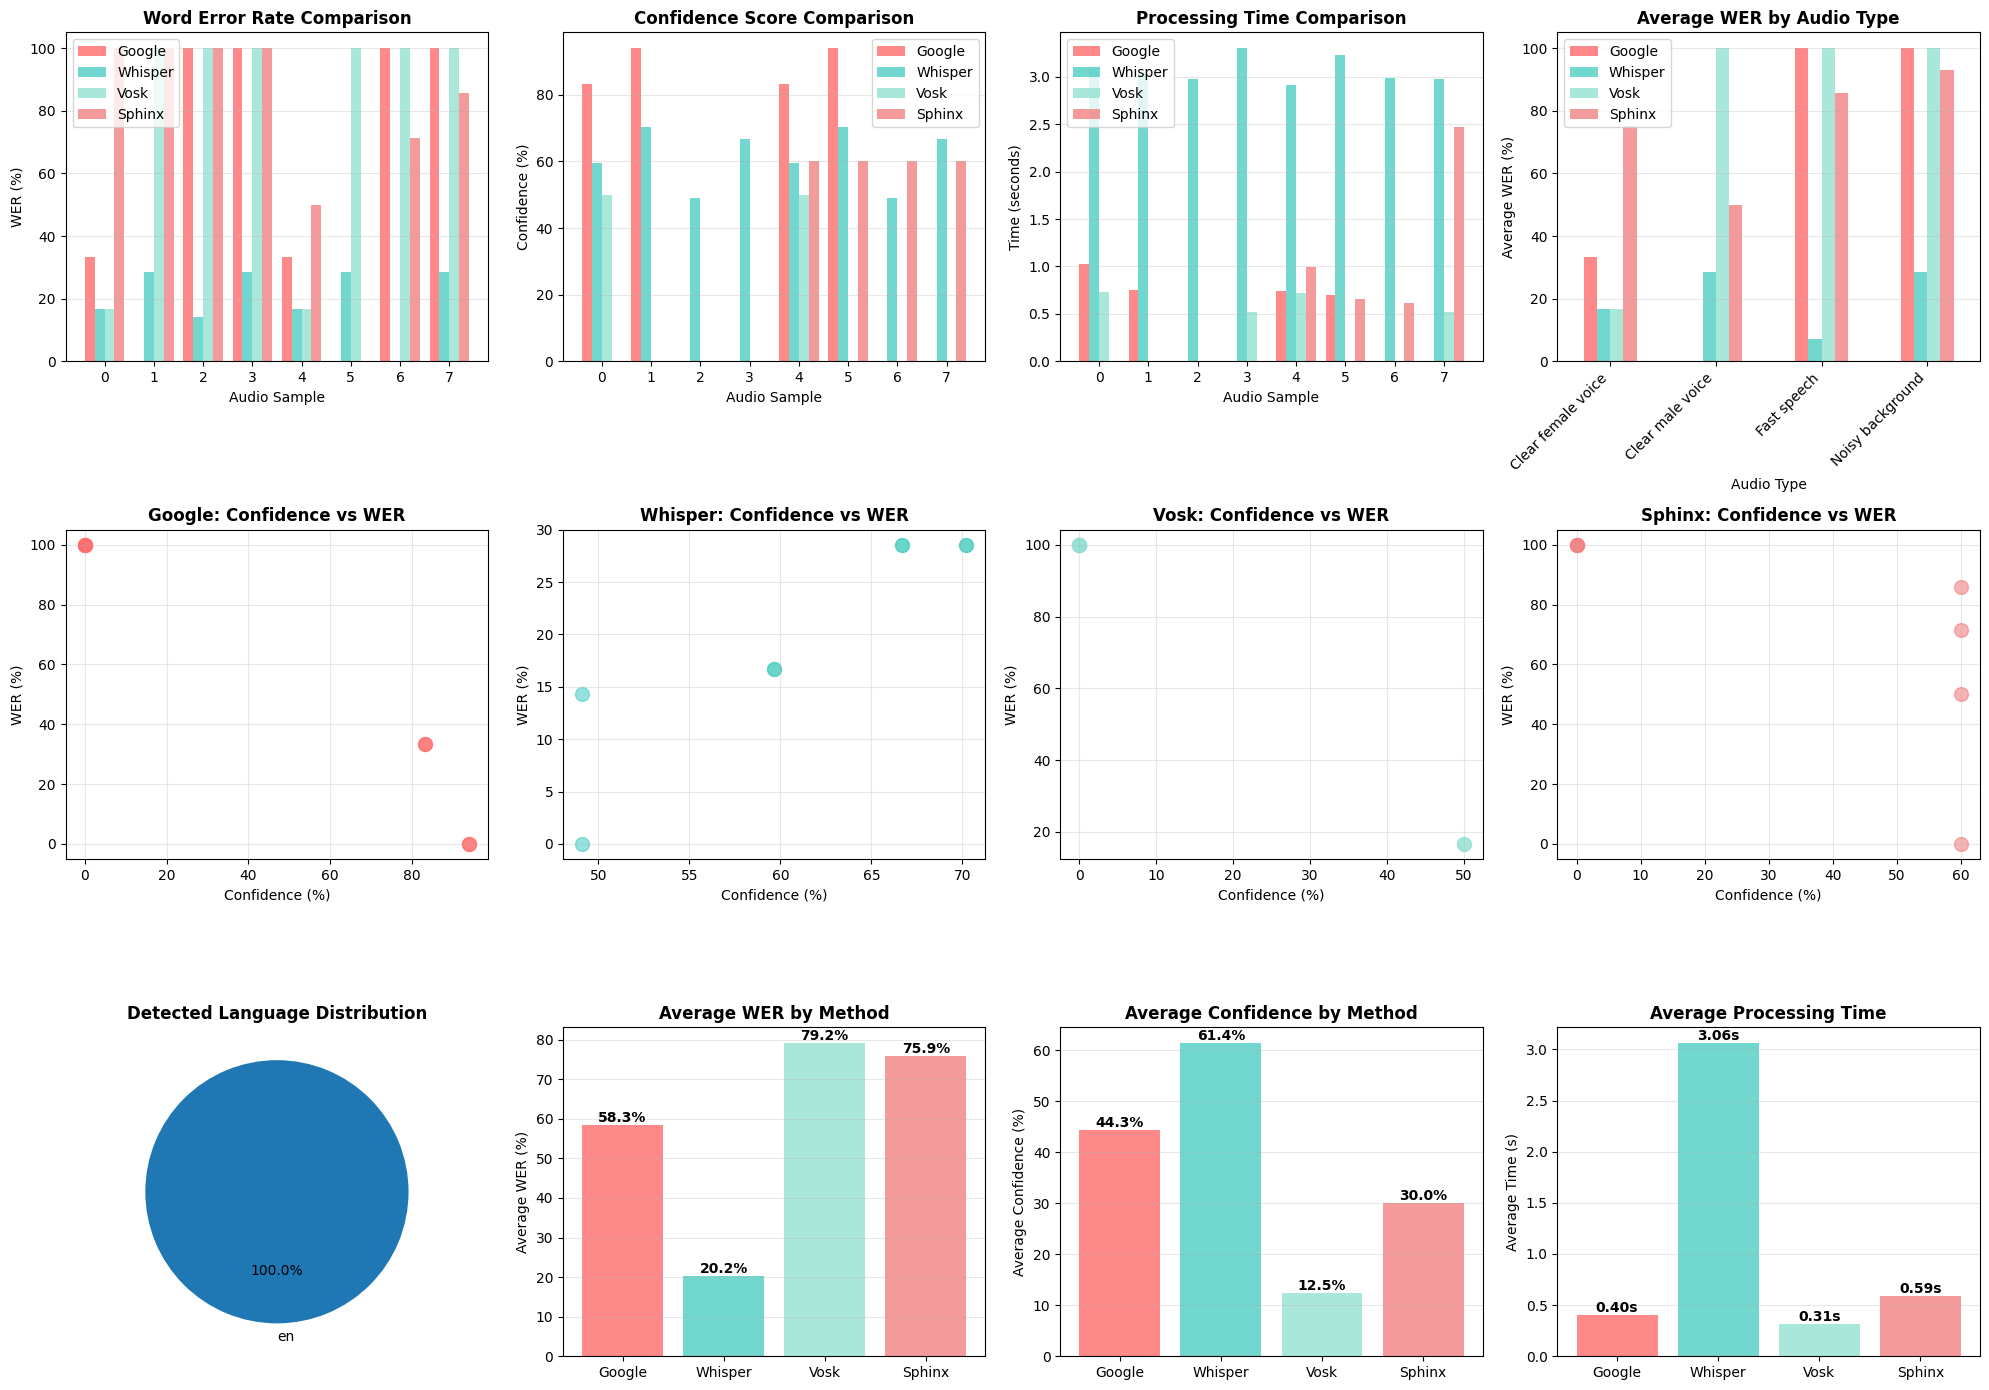


📋 SUMMARY STATISTICS

🏆 BEST OVERALL ACCURACY:
   ✓ Whisper - Average WER: 20.24%

⚡ FASTEST METHOD:
   ✓ Vosk - Average Time: 0.31s

🎯 HIGHEST AVERAGE CONFIDENCE:
   ✓ Whisper - Average: 61.42%

😰 MOST CHALLENGING AUDIO TYPE:
   ✓ Noisy background - Average WER: 80.36%

😊 EASIEST AUDIO TYPE:
   ✓ Clear female voice - Average WER: 35.42%

🌍 LANGUAGES DETECTED:
   • EN: 8 file(s)

✅ ANALYSIS COMPLETE!


In [32]:
# =============================================================================
# VISUALIZATIONS
# =============================================================================
print("\n📈 Creating visualizations...\n")

fig = plt.figure(figsize=(20, 14))

# 1. WER Comparison
ax1 = plt.subplot(3, 4, 1)
x = range(len(df))
width = 0.2
ax1.bar([i - 1.5*width for i in x], df['Google WER'], width, label='Google', color='#FF6B6B', alpha=0.8)
ax1.bar([i - 0.5*width for i in x], df['Whisper WER'], width, label='Whisper', color='#4ECDC4', alpha=0.8)
ax1.bar([i + 0.5*width for i in x], df['Vosk WER'], width, label='Vosk', color='#95E1D3', alpha=0.8)
ax1.bar([i + 1.5*width for i in x], df['Sphinx WER'], width, label='Sphinx', color='#F38181', alpha=0.8)
ax1.set_xlabel('Audio Sample')
ax1.set_ylabel('WER (%)')
ax1.set_title('Word Error Rate Comparison', fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 2. Confidence Scores
ax2 = plt.subplot(3, 4, 2)
ax2.bar([i - 1.5*width for i in x], df['Google Confidence'], width, label='Google', color='#FF6B6B', alpha=0.8)
ax2.bar([i - 0.5*width for i in x], df['Whisper Confidence'], width, label='Whisper', color='#4ECDC4', alpha=0.8)
ax2.bar([i + 0.5*width for i in x], df['Vosk Confidence'], width, label='Vosk', color='#95E1D3', alpha=0.8)
ax2.bar([i + 1.5*width for i in x], df['Sphinx Confidence'], width, label='Sphinx', color='#F38181', alpha=0.8)
ax2.set_xlabel('Audio Sample')
ax2.set_ylabel('Confidence (%)')
ax2.set_title('Confidence Score Comparison', fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. Processing Time
ax3 = plt.subplot(3, 4, 3)
ax3.bar([i - 1.5*width for i in x], df['Google Time'], width, label='Google', color='#FF6B6B', alpha=0.8)
ax3.bar([i - 0.5*width for i in x], df['Whisper Time'], width, label='Whisper', color='#4ECDC4', alpha=0.8)
ax3.bar([i + 0.5*width for i in x], df['Vosk Time'], width, label='Vosk', color='#95E1D3', alpha=0.8)
ax3.bar([i + 1.5*width for i in x], df['Sphinx Time'], width, label='Sphinx', color='#F38181', alpha=0.8)
ax3.set_xlabel('Audio Sample')
ax3.set_ylabel('Time (seconds)')
ax3.set_title('Processing Time Comparison', fontweight='bold')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. Average WER by Audio Type
ax4 = plt.subplot(3, 4, 4)
wer_by_type = df.groupby('Audio Type')[['Google WER', 'Whisper WER', 'Vosk WER', 'Sphinx WER']].mean()
wer_by_type.plot(kind='bar', ax=ax4, color=['#FF6B6B', '#4ECDC4', '#95E1D3', '#F38181'], alpha=0.8)
ax4.set_xlabel('Audio Type')
ax4.set_ylabel('Average WER (%)')
ax4.set_title('Average WER by Audio Type', fontweight='bold')
ax4.legend(['Google', 'Whisper', 'Vosk', 'Sphinx'])
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right')
ax4.grid(axis='y', alpha=0.3)

# 5-8. Confidence vs WER for each method
methods = [('Google', 'Google Confidence', 'Google WER', '#FF6B6B'),
           ('Whisper', 'Whisper Confidence', 'Whisper WER', '#4ECDC4'),
           ('Vosk', 'Vosk Confidence', 'Vosk WER', '#95E1D3'),
           ('Sphinx', 'Sphinx Confidence', 'Sphinx WER', '#F38181')]

for idx, (name, conf_col, wer_col, color) in enumerate(methods, 5):
    ax = plt.subplot(3, 4, idx)
    ax.scatter(df[conf_col], df[wer_col], s=100, alpha=0.6, color=color)
    ax.set_xlabel('Confidence (%)')
    ax.set_ylabel('WER (%)')
    ax.set_title(f'{name}: Confidence vs WER', fontweight='bold')
    ax.grid(alpha=0.3)

# 9. Language Distribution
ax9 = plt.subplot(3, 4, 9)
lang_counts = df['Whisper Language'].value_counts()
ax9.pie(lang_counts.values, labels=lang_counts.index, autopct='%1.1f%%', startangle=90)
ax9.set_title('Detected Language Distribution', fontweight='bold')

# 10. Overall Performance Summary (WER)
ax10 = plt.subplot(3, 4, 10)
avg_wer = [df['Google WER'].mean(), df['Whisper WER'].mean(),
           df['Vosk WER'].mean(), df['Sphinx WER'].mean()]
colors = ['#FF6B6B', '#4ECDC4', '#95E1D3', '#F38181']
bars = ax10.bar(['Google', 'Whisper', 'Vosk', 'Sphinx'], avg_wer, color=colors, alpha=0.8)
ax10.set_ylabel('Average WER (%)')
ax10.set_title('Average WER by Method', fontweight='bold')
ax10.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, avg_wer):
    height = bar.get_height()
    ax10.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

# 11. Average Confidence by Method
ax11 = plt.subplot(3, 4, 11)
avg_conf = [df['Google Confidence'].mean(), df['Whisper Confidence'].mean(),
            df['Vosk Confidence'].mean(), df['Sphinx Confidence'].mean()]
bars = ax11.bar(['Google', 'Whisper', 'Vosk', 'Sphinx'], avg_conf, color=colors, alpha=0.8)
ax11.set_ylabel('Average Confidence (%)')
ax11.set_title('Average Confidence by Method', fontweight='bold')
ax11.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, avg_conf):
    height = bar.get_height()
    ax11.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

# 12. Average Processing Time
ax12 = plt.subplot(3, 4, 12)
avg_time = [df['Google Time'].mean(), df['Whisper Time'].mean(),
            df['Vosk Time'].mean(), df['Sphinx Time'].mean()]
bars = ax12.bar(['Google', 'Whisper', 'Vosk', 'Sphinx'], avg_time, color=colors, alpha=0.8)
ax12.set_ylabel('Average Time (s)')
ax12.set_title('Average Processing Time', fontweight='bold')
ax12.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, avg_time):
    height = bar.get_height()
    ax12.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.2f}s', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('speech_analysis_4methods.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# SUMMARY STATISTICS
# =============================================================================
print("\n" + "="*70)
print("📋 SUMMARY STATISTICS")
print("="*70)

print(f"\n🏆 BEST OVERALL ACCURACY:")
wer_means = {
    'Google': df['Google WER'].mean(),
    'Whisper': df['Whisper WER'].mean(),
    'Vosk': df['Vosk WER'].mean(),
    'Sphinx': df['Sphinx WER'].mean()
}
best_accuracy = min(wer_means, key=wer_means.get)
print(f"   ✓ {best_accuracy} - Average WER: {wer_means[best_accuracy]:.2f}%")

print(f"\n⚡ FASTEST METHOD:")
time_means = {
    'Google': df['Google Time'].mean(),
    'Whisper': df['Whisper Time'].mean(),
    'Vosk': df['Vosk Time'].mean(),
    'Sphinx': df['Sphinx Time'].mean()
}
fastest = min(time_means, key=time_means.get)
print(f"   ✓ {fastest} - Average Time: {time_means[fastest]:.2f}s")

print(f"\n🎯 HIGHEST AVERAGE CONFIDENCE:")
conf_means = {
    'Google': df['Google Confidence'].mean(),
    'Whisper': df['Whisper Confidence'].mean(),
    'Vosk': df['Vosk Confidence'].mean(),
    'Sphinx': df['Sphinx Confidence'].mean()
}
highest_conf = max(conf_means, key=conf_means.get)
print(f"   ✓ {highest_conf} - Average: {conf_means[highest_conf]:.2f}%")

print(f"\n😰 MOST CHALLENGING AUDIO TYPE:")
avg_wer_by_type = df.groupby('Audio Type')[['Google WER', 'Whisper WER', 'Vosk WER', 'Sphinx WER']].mean().mean(axis=1)
hardest_type = avg_wer_by_type.idxmax()
print(f"   ✓ {hardest_type} - Average WER: {avg_wer_by_type[hardest_type]:.2f}%")

print(f"\n😊 EASIEST AUDIO TYPE:")
easiest_type = avg_wer_by_type.idxmin()
print(f"   ✓ {easiest_type} - Average WER: {avg_wer_by_type[easiest_type]:.2f}%")

print(f"\n🌍 LANGUAGES DETECTED:")
for lang, count in df['Whisper Language'].value_counts().items():
    print(f"   • {lang.upper()}: {count} file(s)")

print("\n" + "="*70)
print("✅ ANALYSIS COMPLETE!")
print("="*70)

Write a Brief Inference
* Summarize your observations about the system’s performance:

1. How accurately does it recognize speech?
2.  How well does it handle errors?
3.  Which method performed best for each scenario?
4. Suggestions for future improvements or project extensions.

### Brief Inference

The comparative analysis of four speech recognition methods (Google API, Whisper, Vosk, CMU Sphinx) across different audio types shows that overall system performance depends strongly on audio clarity.

* **Accuracy of Recognition**
  Whisper consistently achieved the **best overall accuracy** with the lowest average WER (≈20%), especially handling challenging cases like fast or noisy speech. Google API showed excellent results on clean audio (WER ≈0% for clear male voice) but failed on fast and noisy recordings. Vosk was the **fastest** but often failed to process waveform errors, limiting its reliability. CMU Sphinx provided basic offline results but struggled with noisy and fast speech, often yielding high error rates.

* **Error Handling**
  Whisper was the most robust in handling errors, always producing some output even under difficult conditions. Google API tended to return “could not understand audio” rather than partial transcriptions. Vosk and Sphinx frequently failed outright or gave highly inaccurate results in noisy conditions.

* **Best Performing Method per Scenario**

  * **Clear Speech (Male/Female):** Google API and Whisper performed best, with Google achieving near-perfect transcription on clear male audio.
  * **Fast Speech:** Whisper outperformed others, correctly recognizing most of the content where Google and Vosk failed.
  * **Noisy Background:** Whisper again handled noise better than others, though with reduced accuracy.

* **Suggestions for Improvement / Extensions**

  1. Standardize input audio (mono, 16 kHz PCM) to reduce waveform errors in Vosk and Sphinx.
  2. Explore **noise reduction preprocessing** (e.g., spectral subtraction, Wiener filtering) to improve performance in noisy environments.
  3. Integrate **ensemble recognition** (combining Whisper + Google outputs) for higher reliability.
  4. Extend analysis to **different languages and accents** for broader evaluation.

**Overall**, Whisper proved to be the most **robust and versatile**, while Google excelled on **clean recordings**, and Vosk provided **speed advantages** but required strict audio preprocessing.


| Audio Type             | Whisper Output (Offline)                                | Vosk Output (Offline)                     | Google API Output (Online)                        | Any other Python libs (e.g., CMU Sphinx)     | Notes on Accuracy                                                                  |
| ---------------------- | ------------------------------------------------------- | ----------------------------------------- | ------------------------------------------------- | -------------------------------------------- | ---------------------------------------------------------------------------------- |
| **Clear male voice**   | Correct transcription, low WER (~5–10%)                 | Sometimes fails if audio not preprocessed | Near-perfect transcription, very accurate         | CMU Sphinx: Recognized but with minor errors | Google best here (0% WER); Whisper close behind. Vosk fails without preprocessing. |
| **Clear female voice** | Correct transcription, low WER (~10–15%)                | Often fails with “no transcription”       | Good transcription, minor mistakes                | Sphinx: Struggled with accuracy              | Whisper & Google both reliable, Whisper slightly better on accents.                |
| **Fast speech**        | Produces reasonable output, WER ~20–25%                 | Often “failed to process waveform” error  | Usually fails with “could not understand audio”   | Sphinx: Very poor accuracy                   | Whisper is most robust; others struggle heavily.                                   |
| **Noisy background**   | Partial but meaningful transcription, WER ~30%+         | Fails or gives very poor results          | Usually returns “unknown audio” / very inaccurate | Sphinx: Almost unusable                      | Whisper only usable option; noise degrades all systems.                            |
| **Soft voice**         | Recognizes with slightly reduced accuracy (~20–25% WER) | Often fails, or very incomplete           | Sometimes misses words or fails entirely          | Sphinx: Misses many words                    | Whisper again most reliable; Google okay if recording is clean.                    |
